# Exploring Encodec

This notebook:
- loads HF `facebook/encodec_24khz`
- reads `.ecdc` (via your `utils.ecdc_utils.load_ecdc`)
- reads audio files and can code them as Encodec token staks or latents  
- builds a per-level lookup table **by decoding each token index** (RNeNcodec-style)  
--      (this is used to map token stacks (or individual tokens) to latents



<div style="width: 100%; height: 10px; background-color: blue;"></div>
<b>Next cell is for when opening this GitHub notebook on https://colab.research.google.com/</b><br>
If you run locally, it is ignored. If you run from collab then you must just set REPO_URL

In [1]:
# ── Environment Setup (Colab + Local compatible) ───────────────────────────
import sys, os, subprocess

IN_COLAB = "google.colab" in sys.modules or "COLAB_GPU" in os.environ

if IN_COLAB:
    REPO_URL = "https://github.com/lonce/EncodecExplorerCore"  # ← UPDATE TO YOUR GITHUHB URL (no extension)
    REPO_DIR = REPO_URL.split("/")[-1]

    if not os.path.isdir(REPO_DIR):
        result = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            raise RuntimeError(f"git clone failed:\n{result.stderr}")

    repo_abs = os.path.abspath(REPO_DIR)
    if repo_abs not in sys.path:
        sys.path.insert(0, repo_abs)
    os.chdir(repo_abs)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
        check=True
    )
    print("Setup complete. Working directory:", os.getcwd())

else:
    print("Local environment detected — skipping installs.")


Local environment detected — skipping installs.


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import EncodecModel

from IPython.display import Audio, display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "facebook/encodec_24khz"

model = EncodecModel.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

print("Loaded:", MODEL_ID)
print("Device:", DEVICE)
print("Model sampling rate:", getattr(model.config, "sampling_rate", None))
print("Codebook size (K):", getattr(model.config, "codebook_size", None))
print("Target bandwidths:", getattr(model.config, "target_bandwidths", None))

Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

Loaded: facebook/encodec_24khz
Device: cpu
Model sampling rate: 24000
Codebook size (K): 1024
Target bandwidths: [1.5, 3.0, 6.0, 12.0, 24.0]


In [3]:
from utils.ecdc_utils import load_wav_mono
from utils.ecdc_utils import load_ecdc  # read a stored ecdc file
from utils.ecdc_utils import  encode_audio_to_tokens #convert an audio to an ecdc representation

from utils.ecdc_utils import bandwidth_to_n_q, n_q_to_bandwidth

# Creates the lookup table for an Encodec model to use for token-> latent mapping
from utils.ecdc_utils import  build_LOOKUP_via_layer_decode

# Creates a "pool" of tokens that can be drawn on for style transfer purposes
from utils.ecdc_utils import  tokens_to_summary_latents

# returns tensor of latents for just one level of a token stack sequence
from utils.ecdc_utils import  token_level_to_latents

# take an audio segment to a tensor of encodec latents
from utils.ecdc_utils import  audio_to_latents

from utils.ecdc_utils import  latents128_to_audio, tokens_TN_to_audio_1T
#=======================

from utils.ecdc_utils import latents128_to_audio_streaming

# imports specifically for the Tokui-like style transfer


<div style="width: 100%; height: 2px; background-color: red;"></div>
Tensor ordering is a mess between HF (Hugging Face, Encodec, and canonical). <br>
<span style="color: red;">
      - "TN":  [T_frames, n_q]      (recommended canonical)  <br>  
      - "BQT": [B, n_q, T_frames]   (HuggingFace-friendly)  <br>  
      - "QBT": [n_q, B, T_frames]   (for model.quantizer.decode)  <br>  
</span>

<div style="width: 100%; height: 30px; background-color: green;"></div>
<b>Utility Functions for your coding pleasure</b><br>

<span style="color: blue;">
Translate between Encodec "bandwidth" representations
bandwidths (kbs): [1.5, 3.0, 6.0, 12.0, 24.0] <->  number of codebooks (n_q): [2, 4, 8, 16, 32]  
</span> <br>
bandwidth_to_n_q(bw_kbps)  
n_q_to_bandwidth(n_q)   
<br><br>

<span style="color: blue;">
Builds the datastructure for mapping tokens to latents   
</span> <br>
build_LOOKUP_via_layer_decode(model, n_q, K_codbook_size, device=DEVICE)
<br><br>

<span style="color: blue;">
Uses the loopkup table datastructure to map tokens to latents   
</span> <br>
tokens_to_summary_latents(tokens_TN, LOOKUP_QKD )    <br>
(First arg in (T, N) form, Second arg is datastructure mapping tokens to latents)  
<br><br>



<span style="color: blue;">
Returns latents for a single cobook level of codes
</span> <br>
token_level_to_latents(tokens_TN: torch.Tensor, level_q: int, LOOKUP_QKD: torch.Tensor)    
<br><br>

<span style="color: blue;">
Encodes an audio signal to tokens
</span> <br>
encode_audio_to_tokens(audio, model, DEVICE, n_q_to_bandwidth(8))  
<br><br>

<span style="color: blue;">
Returns latents for an audio signal
</span> <br>
audio_to_latents(audio, model, device: str, bandwidth)  
<br><br>


<span style="color: blue;">
(T,N) tensor of latents to audio  
</span> <br>
latents128_to_audio(model, z_T128, device)  
<br><br>

<span style="color: blue;">
(T,N) tensor of tokens to audio  
</span> <br>
tokens_TN_to_audio_1T(model, tokens_TN: torch.Tensor, device, audio_scales=None, last_frame_pad_length: int = 0)  
<br><br>



<div style="width: 100%; height: 10px; background-color: green;"></div>
We use the names "pool" and "target" for the two sounds we load below.

In [4]:

if 0: # Load the "pool" from an.ecdc file (tokens_TN is (T, n_q)) ----
    dspath = "ecdc/DSPeepers--max_range-00.55--c-02--x-98.ecdc"
    pool_tokens_TN, scales, raw = load_ecdc(dspath)
else : # OR from audio
    #dspath = "wav24k/amen_mono_24k.wav" # "wav24k/diverse24.wav"
    dspath = "wav24k/bells24.wav"
    pool_audio=load_wav_mono(dspath)
    pool_tokens_TN, raw = encode_audio_to_tokens(pool_audio, model, DEVICE, n_q_to_bandwidth(8))
    scales = getattr(raw, "audio_scales", None)


encode_audio_to_tokens with n_q=8


In [5]:
#show some info about the pool
n_q= pool_tokens_TN.shape[1]
print("pool_tokens_TN:", pool_tokens_TN.shape, pool_tokens_TN.dtype)   # (T, n_q)
print("n_q:", n_q)
print("scales:", scales)
print("raw keys:", list(raw.keys()))
print("audio_length:", raw.get("audio_length"))

pool_tokens_TN: torch.Size([4241, 8]) torch.int64
n_q: 8
scales: [None]
raw keys: ['audio_codes', 'audio_scales', 'last_frame_pad_length']
audio_length: None


<div style="width: 100%; height: 10px; background-color: green;"></div>
<b>Create the lookup table for using in function taking codes -> latents </b>

In [6]:
# Create lookup table (with same number of codebooks as poos) for fast token->latent mapping
K = int(getattr(model.config, "codebook_size", 1024))
n_q_data = int(pool_tokens_TN.shape[1])
LOOKUP_QKD = build_LOOKUP_via_layer_decode(model, n_q=n_q_data, K=K, device=DEVICE)
print("LOOKUP_QKD:", LOOKUP_QKD.shape, LOOKUP_QKD.dtype, LOOKUP_QKD.device)

LOOKUP_QKD: torch.Size([8, 1024, 128]) torch.float32 cpu


<div style="width: 100%; height: 10px; background-color: green;"></div>
<b>POOL  latents</b>

In [7]:
# now use the lookup table to first create the "pool" of latents
pool_latents = tokens_to_summary_latents(pool_tokens_TN, LOOKUP_QKD)
print("pool_latents:", pool_latents.shape, pool_latents.dtype, pool_latents.device)


Taking tokens_to_summary_latents with n_q=8
pool_latents: torch.Size([4241, 128]) torch.float32 cpu


In [8]:
pool_latents_audio = latents128_to_audio(model, pool_latents[:450], DEVICE).cpu()
display(Audio(pool_latents_audio, rate=24000))

<div style="width: 100%; height: 10px; background-color: green;"></div>
<b>TARGET latents</b>

In [9]:
target_audio=load_wav_mono("wav24k/amen_mono_24k.wav")
print(f'DEVICE is {DEVICE}')
target_latents, _, _ = audio_to_latents(target_audio, model, DEVICE, n_q_to_bandwidth(n_q))
print("target_latents:", target_latents.shape, target_latents.dtype, target_latents.device)

# lets just make sure when we convert the latents back to audio it sound right.
test_target_audio= latents128_to_audio(model, target_latents, DEVICE).cpu()
display(Audio(test_target_audio, rate=24000))

DEVICE is cpu
encode_audio_to_tokens with n_q=8
target_latents: torch.Size([524, 128]) torch.float32 cpu


<div style="width: 100%; height: 10px; background-color: green;"></div>
<b>Visualization / Exploration </b> <br>
Compare non streaming to streaming (with chunk and hop size)

In [10]:
##########   First do normal encodec decoding (non streaming)    #################

nonstream_pool_audio = latents128_to_audio(model, pool_latents[:450], DEVICE).cpu()
print(f'non-streaming')
display(Audio(nonstream_pool_audio, rate=24000))

##########    Now do the streaming reconstruction setting chunk and up lengths   #################
chunk_length = 2 
hop_length   = 2                                                                     
stream_pool_audio = latents128_to_audio_streaming(model, pool_latents[:450], DEVICE, chunk_length, hop_length).cpu()
print(f'chunck_length={chunk_length}, hop_length={hop_length}')
display(Audio(stream_pool_audio, rate=24000))


non-streaming


chunck_length=2, hop_length=2


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# audio can be a torch tensor or numpy array, shape [T] or [1,T] or [C,T]
# sr = sample rate (Hz)

def plot_audio(audio, sr, title="Audio waveform", max_points=200_000):
    # ---- convert to 1D numpy ----
    if "torch" in str(type(audio)):
        audio = audio.detach().cpu().float().numpy()

    audio = np.asarray(audio)

    # handle [1,T] or [C,T]
    if audio.ndim == 2:
        # pick first channel
        audio = audio[0]

    audio = audio.squeeze()
    if audio.ndim != 1:
        raise ValueError(f"Expected 1D audio after squeezing, got shape {audio.shape}")

    T = audio.shape[0]
    t = np.arange(T) / float(sr)

    # ---- downsample for faster plotting ----
    if T > max_points:
        idx = np.linspace(0, T - 1, max_points).astype(np.int64)
        audio_plot = audio[idx]
        t_plot = t[idx]
    else:
        audio_plot = audio
        t_plot = t

    plt.figure(figsize=(12, 3))
    plt.plot(t_plot, audio_plot)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.show()


# Example usage:
# plot_audio(audio_1T, sr=24000, title="Streaming decode")

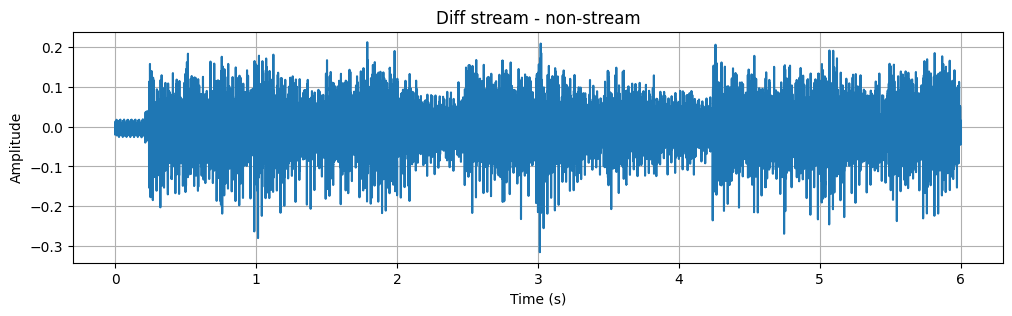

In [12]:
# show *difference*  between nonstreaming and streaming audio 
plot_audio(stream_pool_audio-nonstream_pool_audio, 24000, "Diff stream - non-stream")

<div style="width: 100%; height: 3px; background-color: green;"></div>
<b> Signal types </b> <br>
Sine sweep from 880 to 220 Hz over 6 seconds <br>
Compare losses for codebook stack depth to streaming parameters

In [13]:
dspath = "wav24k/linearsinglide880.220_sr24.wav"
sin_audio=load_wav_mono(dspath)

sin_tokens_TN, raw = encode_audio_to_tokens(sin_audio, model, DEVICE, n_q_to_bandwidth(8))
sin_latents = tokens_to_summary_latents(sin_tokens_TN, LOOKUP_QKD)

###########   choose your streaming parameters, chunk ahd hop lengths ##############
cl=4
hl=2
print(f'chunck_length={cl}, hop_length={hl}')
sin_latents_audio =  latents128_to_audio_streaming(model, sin_latents, DEVICE, cl, hl).cpu()
display(Audio(sin_latents_audio, rate=24000))


encode_audio_to_tokens with n_q=8
Taking tokens_to_summary_latents with n_q=8
chunck_length=4, hop_length=2


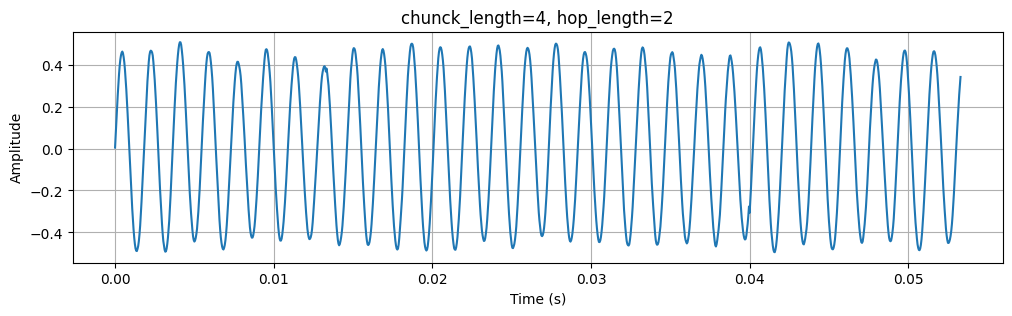

In [14]:
startsamp=3*24000
frames = 4
spf=320 #24000/75
endsamp=startsamp+frames*spf

plot_audio(sin_latents_audio[0, startsamp:endsamp], 24000, f'chunck_length={cl}, hop_length={hl}')